In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))
from src import *

In [2]:
#Extracting File from Preprocessed data

df = pd.read_csv("../data/processed/telco_processed.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


In [3]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,AvgMonthlySpend,ServiceCount,ContractValue
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,29.850000,1,29.85
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,55.573529,3,1936.30
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,3,107.70
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,40.905556,3,1903.50
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,1,141.40


Accuracy : 0.8098391674550615
Precision: 0.6904761904761905
Recall   : 0.5160142348754448
F1 Score : 0.5906313645621182
ROC-AUC  : 0.8450352203103791

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.92      0.88       776
           1       0.69      0.52      0.59       281

    accuracy                           0.81      1057
   macro avg       0.76      0.72      0.73      1057
weighted avg       0.80      0.81      0.80      1057



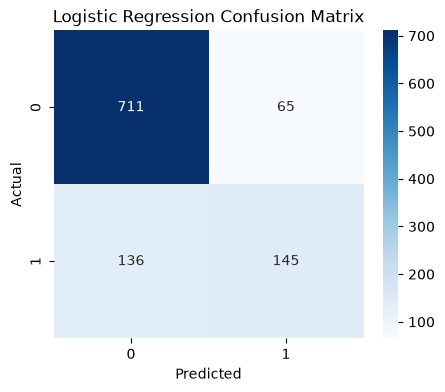

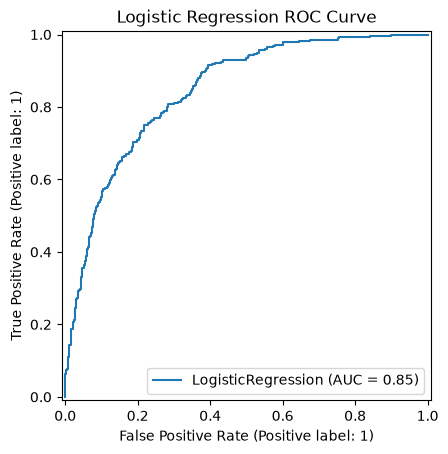

In [4]:
#Logistic Regression
#Classification (Churn prediction)
#So considering churn as separate column
#set random state =42
#splitting of data
X_train, X_val, X_test, y_train, y_val, y_test = split_data(df)
best_lr, training_time=train_logistic(X_train,y_train)

# Predictions
y_pred, y_prob=predictions_c(X_test,best_lr)

# Metrics
accuracy, precision, recall, f1, roc_auc = classification_metrics(
    y_test,
    y_pred,
    y_prob
)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

#Confusion Matrix Logistic Regression
cm = plot_confusion_matrix(
    y_test,
    y_pred,
    "Logistic Regression"
)
#ROC curve  Logistic Regression
plot_roc_curve(best_lr,
    X_test,
    y_test,
    "Logistic Regression")
results = []

results.append([
    "Logistic Regression",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

Accuracy : 0.7511825922421949
Precision: 0.5298013245033113
Recall   : 0.5693950177935944
F1 Score : 0.548885077186964
ROC-AUC  : 0.7823105073925964
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       776
           1       0.53      0.57      0.55       281

    accuracy                           0.75      1057
   macro avg       0.68      0.69      0.69      1057
weighted avg       0.76      0.75      0.75      1057



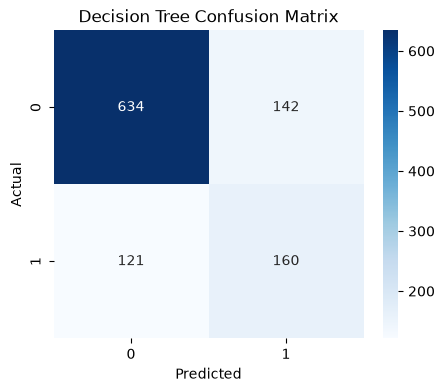

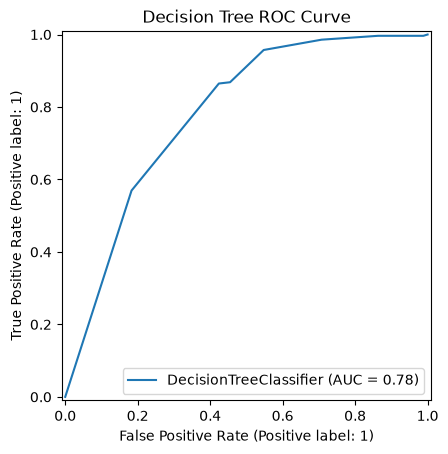

In [5]:
#Decision tree classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
best_dt, training_time=train_decision_tree(X_train,y_train)
#Predictions
y_pred, y_prob=predictions_c(X_test,best_dt)

# Metrics
accuracy, precision, recall, f1, roc_auc = classification_metrics(
    y_test,
    y_pred,
    y_prob
)

#Classification report
print(classification_report(y_test, y_pred))

#Confusion Matrix Decision Tree
cm = plot_confusion_matrix(
    y_test,
    y_pred,
    "Decision Tree"
)
#ROC curve Decision Tree
plot_roc_curve(best_dt,
    X_test,
    y_test,
    "Decision Tree")


results.append([
    "Decision Tree",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

Accuracy : 0.7890255439924314
Precision: 0.6464646464646465
Recall   : 0.4555160142348754
F1 Score : 0.534446764091858
ROC-AUC  : 0.8353152401218035
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       776
           1       0.65      0.46      0.53       281

    accuracy                           0.79      1057
   macro avg       0.73      0.68      0.70      1057
weighted avg       0.78      0.79      0.78      1057



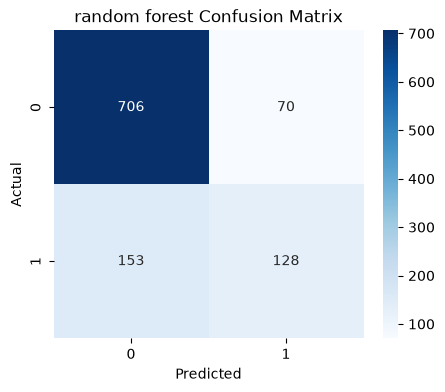

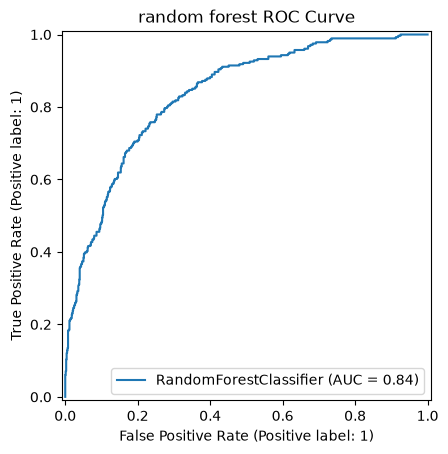

In [6]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


best_rf, training_time=train_random_forest(X_train,y_train)
#Predictions
y_pred, y_prob=predictions_c(X_test,best_rf)
#Metrics
accuracy, precision, recall, f1, roc_auc = classification_metrics(
    y_test,
    y_pred,
    y_prob
)

#Classification report
print(classification_report(y_test, y_pred))

#Confusion Matrix 
cm = plot_confusion_matrix(
    y_test,
    y_pred,
    "random forest"
)
#ROC curve 
plot_roc_curve(best_rf,
    X_test,
    y_test,
    "random forest")
results.append([
    "Random Forest",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])

In [7]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values(
    ascending=False
).head(10)

tenure                            0.132955
TotalCharges                      0.122002
ContractValue                     0.109791
AvgMonthlySpend                   0.091558
MonthlyCharges                    0.089572
PaymentMethod_Electronic check    0.054983
Contract_Two year                 0.049061
InternetService_Fiber optic       0.047149
Contract_One year                 0.029093
OnlineSecurity_Yes                0.025624
dtype: float64

#Random Forest Classifier completed

C:\Users\BALAJI REDDY U\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Accuracy : 0.6830652790917692
Precision: 0.4262295081967213
Recall   : 0.5551601423487544
F1 Score : 0.482225656877898
ROC-AUC  : 0.72536871262428
              precision    recall  f1-score   support

           0       0.82      0.73      0.77       776
           1       0.43      0.56      0.48       281

    accuracy                           0.68      1057
   macro avg       0.62      0.64      0.63      1057
weighted avg       0.71      0.68      0.69      1057



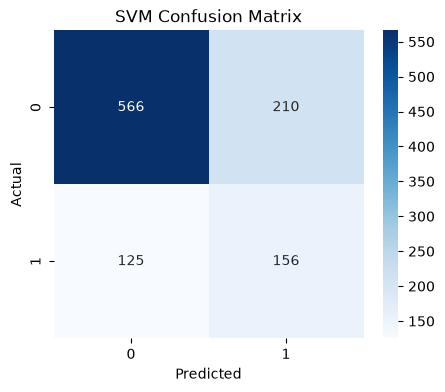

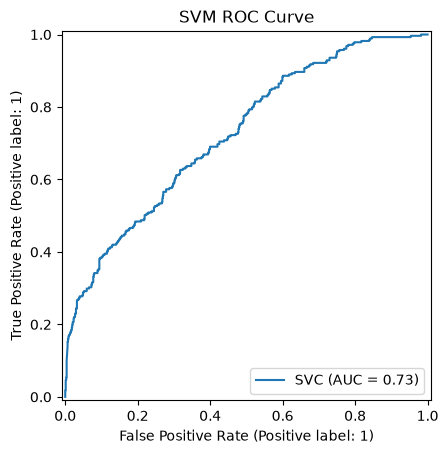

In [8]:
#Calculating training time
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


best_svm, training_time=train_svm(X_train,y_train)
#Predictions
y_pred, y_prob=predictions_c(X_test,best_svm)
#Metrics
accuracy, precision, recall, f1, roc_auc = classification_metrics(
    y_test,
    y_pred,
    y_prob
)

#Classification report
print(classification_report(y_test, y_pred))

#Confusion Matrix 
cm = plot_confusion_matrix(
    y_test,
    y_pred,
    "SVM"
)
#ROC curve 
plot_roc_curve(best_svm,
    X_test,
    y_test,
    "SVM")
results.append([
    "SVM",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])



Accuracy : 0.7795648060548723
Precision: 0.6363636363636364
Recall   : 0.398576512455516
F1 Score : 0.49015317286652077
ROC-AUC  : 0.7572252082033972
              precision    recall  f1-score   support

           0       0.81      0.92      0.86       776
           1       0.64      0.40      0.49       281

    accuracy                           0.78      1057
   macro avg       0.72      0.66      0.67      1057
weighted avg       0.76      0.78      0.76      1057



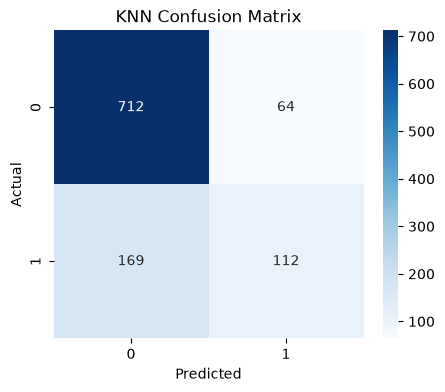

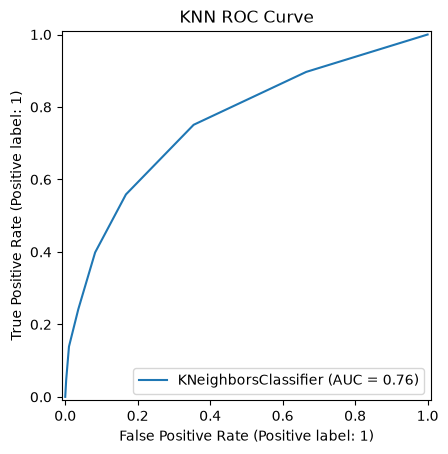

In [9]:
#k-Nearest Neighbours(KNN) classifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
best_knn, training_time=train_knn(X_train,y_train)
#Predictions
y_pred, y_prob=predictions_c(X_test,best_knn)
#Metrics
accuracy, precision, recall, f1, roc_auc = classification_metrics(
    y_test,
    y_pred,
    y_prob
)

#Classification report
print(classification_report(y_test, y_pred))

#Confusion Matrix 
cm = plot_confusion_matrix(
    y_test,
    y_pred,
    "KNN"
)
#ROC curve 
plot_roc_curve(best_knn,
    X_test,
    y_test,
    "KNN")
results.append([
    "KNN",
    accuracy,
    precision,
    recall,
    f1,
    roc_auc,
    training_time
])



In [10]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Training Time"
    ]
)

results_df.sort_values(
    by="ROC-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time
0,Logistic Regression,0.809839,0.690476,0.516014,0.590631,0.845035,5.405131
2,Random Forest,0.789026,0.646465,0.455516,0.534447,0.835315,6.360059
1,Decision Tree,0.751183,0.529801,0.569395,0.548885,0.782311,0.869102
4,KNN,0.779565,0.636364,0.398577,0.490153,0.757225,0.733571
3,SVM,0.683065,0.426230,0.555160,0.482226,0.725369,8.059817


In [11]:
#Logistic regression is the best model

In [12]:
import pickle

with open("../models/best_classifier.pkl", "wb") as f:
    pickle.dump(best_lr, f)

print("Classifier saved!")


Classifier saved!


In [13]:
import pickle

with open("../models/best_classifier.pkl", "rb") as f:
    model = pickle.load(f)

print(type(model))
print(model)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
LogisticRegression(C=100, max_iter=5000, solver='liblinear')


In [14]:
preds = model.predict(X_test.head())

print(preds)

[0 0 0 0 0]
